## Step 1: Import Libraries

In [17]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from textblob import TextBlob
from nltk.corpus import stopwords

sns.set(style="whitegrid")
%matplotlib inline


## Step 2: Collect Student Feedback Data

The raw file has messy duplicate column names (e.g. `teaching`, `teaching.1`), so rename them by position right after loading.

In [18]:
df = pd.read_excel(r"C:\files\AU jupyter\NLP\finalDataset0.2.xlsx")

df.columns = ["teaching_score", "teaching_label",
              "coursecontent_score", "coursecontent_label",
              "examination_score", "examination_label",
              "labwork_score", "labwork_label",
              "library_score", "library_label",
              "extracurricular_score", "extracurricular_label"]

df.head()


,teaching_score,teaching_label,coursecontent_score,coursecontent_label,examination_score,examination_label,labwork_score,labwork_label,library_score,library_label,extracurricular_score,extracurricular_label
0,0,teacher are punctual but they should also give...,0.0,content of courses are average,1.0,examination pattern is good,-1,"not satisfactory, lab work must include latest...",0.0,library facilities are good but number of book...,1,extracurricular activities are excellent and p...
1,1,Good,-1.0,Not good,1.0,Good,1,Good,-1.0,Not good,1,Good
2,1,Excellent lectures are delivered by teachers a...,1.0,All courses material provide very good knowled...,1.0,Exam pattern is up to the mark and the Cgpa de...,1,Lab work is properly covered in the labs by th...,1.0,Library facilities are excellent in terms of g...,1,Extra curricular activities also help students...
3,1,Good,-1.0,Content of course is perfectly in line with th...,-1.0,Again the university tests students of their a...,1,Good,0.0,Its the best thing i have seen in this univers...,-1,Complete wastage of time. Again this opinion i...
4,1,teachers give us all the information required ...,1.0,content of courses improves my knowledge,1.0,examination pattern is good,1,practical work provides detail knowledge of th...,1.0,library has huge collection of books from diff...,1,extracurricular activities increases mental an...


In [19]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   teaching_score         185 non-null    int64  
 1   teaching_label         185 non-null    object 
 2   coursecontent_score    184 non-null    float64
 3   coursecontent_label    185 non-null    object 
 4   examination_score      184 non-null    float64
 5   examination_label      185 non-null    object 
 6   labwork_score          185 non-null    int64  
 7   labwork_label          185 non-null    object 
 8   library_score          182 non-null    float64
 9   library_label          185 non-null    object 
 10  extracurricular_score  185 non-null    int64  
 11  extracurricular_label  185 non-null    object 
dtypes: float64(3), int64(3), object(6)
memory usage: 17.5+ KB


In [20]:
df.isnull().sum()


teaching_score           0
teaching_label           0
coursecontent_score      1
coursecontent_label      0
examination_score        1
examination_label        0
labwork_score            0
labwork_label            0
library_score            3
library_label            0
extracurricular_score    0
extracurricular_label    0
dtype: int64

In [21]:
df= df.dropna()

In [22]:
df.isnull().sum()

teaching_score           0
teaching_label           0
coursecontent_score      0
coursecontent_label      0
examination_score        0
examination_label        0
labwork_score            0
labwork_label            0
library_score            0
library_label            0
extracurricular_score    0
extracurricular_label    0
dtype: int64

## Step 3: Preprocess Feedback Text

Clean each category's comment (lowercase, remove punctuation, remove stopwords), then combine all six into one full feedback text per student.

In [23]:
label_cols = ["teaching_label", "coursecontent_label", "examination_label",
              "labwork_label", "library_label", "extracurricular_label"]

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

for col in label_cols:
    df["clean_" + col] = df[col].apply(clean_text)

df["feedback_text"] = df[label_cols].astype(str).agg(" ".join, axis=1)
df["clean_feedback"] = df["feedback_text"].apply(clean_text)

df[["feedback_text", "clean_feedback"]].head()


,feedback_text,clean_feedback
0,teacher are punctual but they should also give...,teacher punctual also give us practical knowle...
1,Good Not good Good Good Not good Good,good good good good good good
2,Excellent lectures are delivered by teachers a...,excellent lectures delivered teachers teachers...
3,Good Content of course is perfectly in line wi...,good content course perfectly line teaching ph...
4,teachers give us all the information required ...,teachers give us information required improve ...


## Step 4: Perform Sentiment Analysis

Use TextBlob to score each student's overall combined feedback, and also score each category separately.

In [24]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["overall_polarity"] = df["clean_feedback"].apply(lambda x: TextBlob(x).sentiment.polarity)
df["overall_sentiment"] = df["overall_polarity"].apply(lambda p: "Positive" if p > 0 else ("Negative" if p < 0 else "Neutral"))

for col in label_cols:
    df[col.replace("_label", "_sentiment")] = df["clean_" + col].apply(get_sentiment)

df[["clean_feedback", "overall_polarity", "overall_sentiment"]].head()


,clean_feedback,overall_polarity,overall_sentiment
0,teacher punctual also give us practical knowle...,0.511905,Positive
1,good good good good good good,0.700000,Positive
2,excellent lectures delivered teachers teachers...,0.540000,Positive
3,good content course perfectly line teaching ph...,0.457143,Positive
4,teachers give us information required improve ...,0.166667,Positive


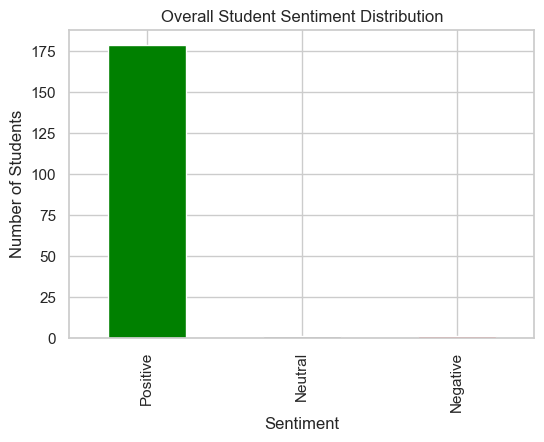

In [25]:
sentiment_counts = df["overall_sentiment"].value_counts()

plt.figure(figsize=(6,4))
sentiment_counts.plot(kind="bar", color=["green","gray","red"])
plt.title("Overall Student Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Students")
plt.show()


## Step 5: Identify Common Student Concerns

Compare sentiment across the 6 categories to see which areas get the most negative feedback.

In [26]:
sentiment_cols = [c.replace("_label", "_sentiment") for c in label_cols]

concern_counts = {}
for col in sentiment_cols:
    concern_counts[col.replace("_sentiment", "")] = (df[col] == "Negative").sum()

concern_series = pd.Series(concern_counts).sort_values(ascending=False)
concern_series


labwork            17
teaching           12
coursecontent      12
examination        12
library            10
extracurricular     7
dtype: int64

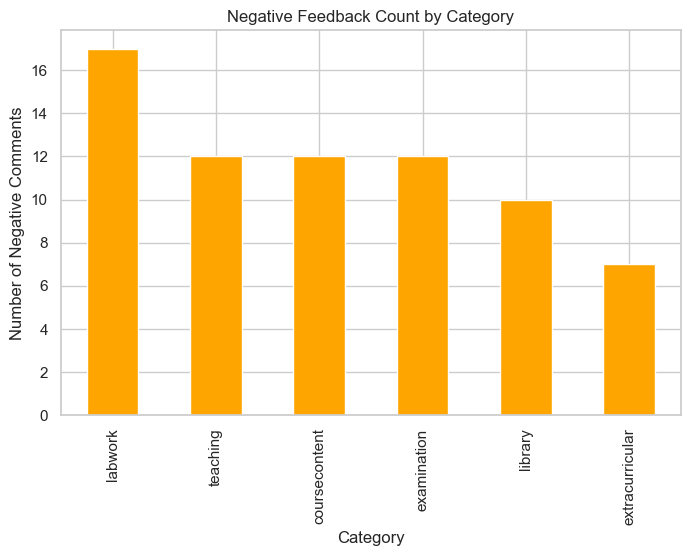

In [27]:
plt.figure(figsize=(8,5))
concern_series.plot(kind="bar", color="orange")
plt.title("Negative Feedback Count by Category")
plt.ylabel("Number of Negative Comments")
plt.xlabel("Category")
plt.show()


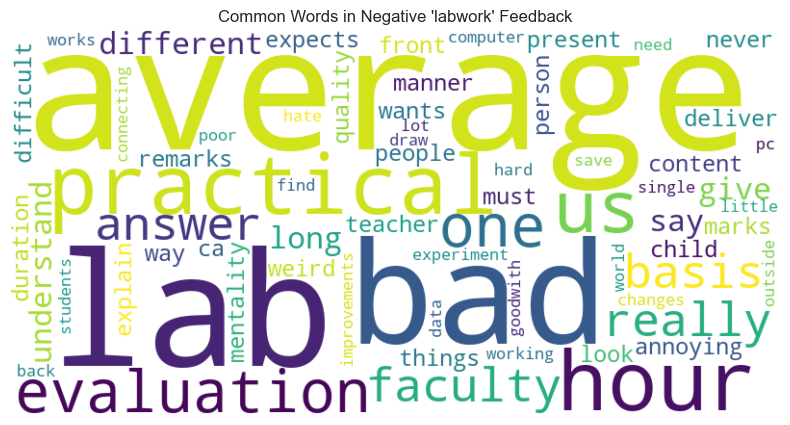

In [28]:
weakest_category = concern_series.index[0]
weakest_col = "clean_" + weakest_category + "_label"
negative_mask = df[weakest_category + "_sentiment"] == "Negative"
negative_text = " ".join(df.loc[negative_mask, weakest_col])

wc = WordCloud(width=800, height=400, background_color="white").generate(negative_text)
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title(f"Common Words in Negative '{weakest_category}' Feedback")
plt.show()


## Step 6: Prepare Improvement Suggestions

Generate rule-based suggestions for the categories with the most negative feedback.

In [29]:
suggestions = {
    "teaching": "Improve teaching methods with more interactive and student-friendly sessions.",
    "coursecontent": "Update course content to stay relevant and add more practical examples.",
    "examination": "Review examination pattern and provide better preparation guidance.",
    "labwork": "Increase lab hours and improve availability of lab resources and equipment.",
    "library": "Expand library resources and improve access to study material.",
    "extracurricular": "Introduce more extracurricular activities and clubs for student engagement."
}

top_concerns = concern_series.head(3)

print("Top areas needing improvement:\n")
for category, count in top_concerns.items():
    print(f"- {category} ({count} negative comments)")
    print(f"  Suggestion: {suggestions[category]}\n")


Top areas needing improvement:

- labwork (17 negative comments)
  Suggestion: Increase lab hours and improve availability of lab resources and equipment.

- teaching (12 negative comments)
  Suggestion: Improve teaching methods with more interactive and student-friendly sessions.

- coursecontent (12 negative comments)
  Suggestion: Update course content to stay relevant and add more practical examples.

